In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df = pd.read_csv(r'student_placement.csv')
df.head()

,cgpa,projects,communication_skills,internship,programming_skills,technical_skills,certifications,aptitude,interview_score,placement_status,package_range
0,7.02,3,6.1,0,7.6,5.7,1,71.6,65.1,0,0
1,7.84,0,6.3,0,5.8,6.9,1,73.0,60.1,1,3-5 LPA
2,6.96,3,8.0,0,6.5,6.0,2,71.6,66.5,1,5-7 LPA
3,7.57,4,5.4,1,6.6,7.4,0,79.0,63.2,1,5-7 LPA
4,5.62,3,7.0,0,5.3,5.3,2,50.8,62.3,0,0


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  4300 non-null   float64
 1   projects              4300 non-null   int64  
 2   communication_skills  4300 non-null   float64
 3   internship            4300 non-null   int64  
 4   programming_skills    4300 non-null   float64
 5   technical_skills      4300 non-null   float64
 6   certifications        4300 non-null   int64  
 7   aptitude              4300 non-null   float64
 8   interview_score       4300 non-null   float64
 9   placement_status      4300 non-null   int64  
 10  package_range         4300 non-null   str    
dtypes: float64(6), int64(4), str(1)
memory usage: 390.5 KB


In [104]:
df.duplicated().sum()

np.int64(0)

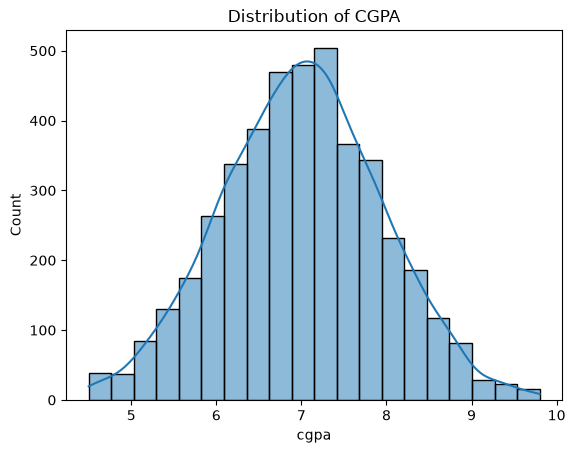

In [105]:
sns.histplot(data = df, x = 'cgpa', bins = 20, kde = True)
plt.title('Distribution of CGPA')
plt.show()

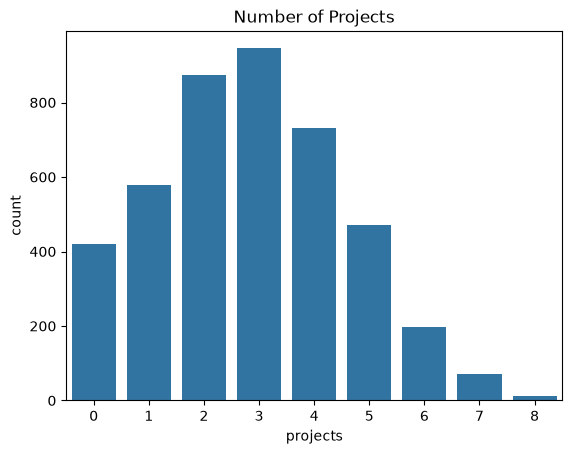

In [106]:
sns.countplot(data = df, x = 'projects')
plt.title('Number of Projects')
plt.show()

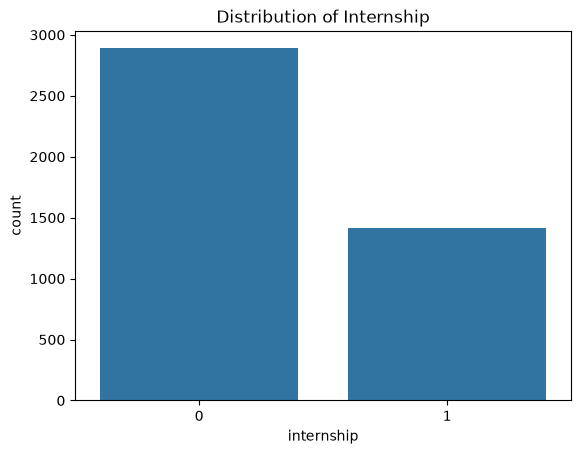

In [107]:
sns.countplot(data = df, x = 'internship')
plt.title('Distribution of Internship')
plt.show()

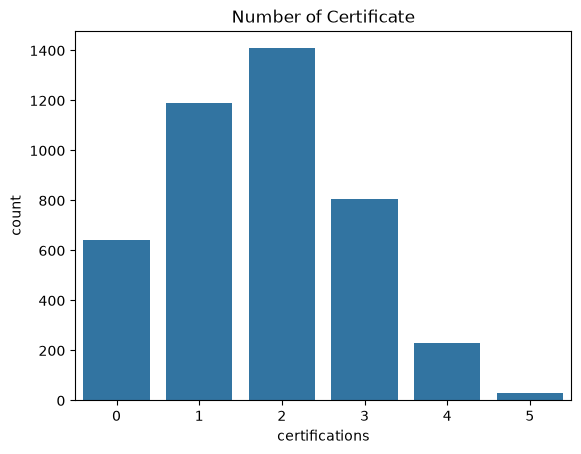

In [108]:
sns.countplot(data = df, x = 'certifications')
plt.title('Number of Certificate')
plt.show()

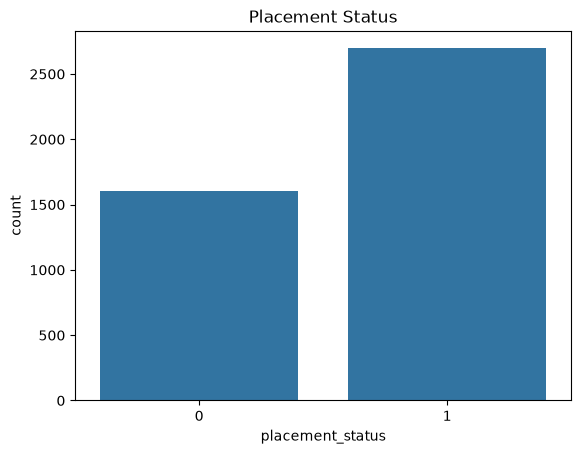

placement_status
1    62.674419
0    37.325581
Name: proportion, dtype: float64


In [109]:
sns.countplot(data=df, x='placement_status')
plt.title('Placement Status')
plt.show()
print(df['placement_status'].value_counts(normalize=True) * 100)

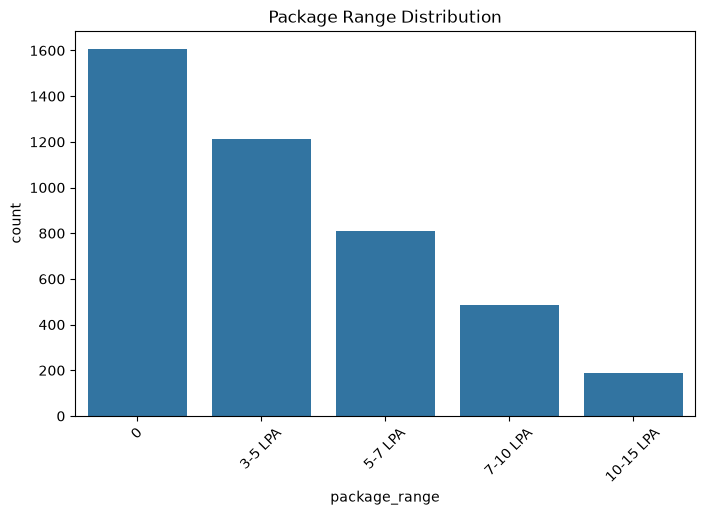

In [110]:
plt.figure(figsize=(8, 5))
sns.countplot(data = df, x = 'package_range', order = df['package_range'].value_counts().index)
plt.title('Package Range Distribution')
plt.xticks(rotation = 45)
plt.show()

In [111]:
numeric_cols = [
    'cgpa',
    'projects',
    'communication_skills',
    'internship',
    'programming_skills',
    'technical_skills',
    'certifications',
    'aptitude',
    'interview_score'
]

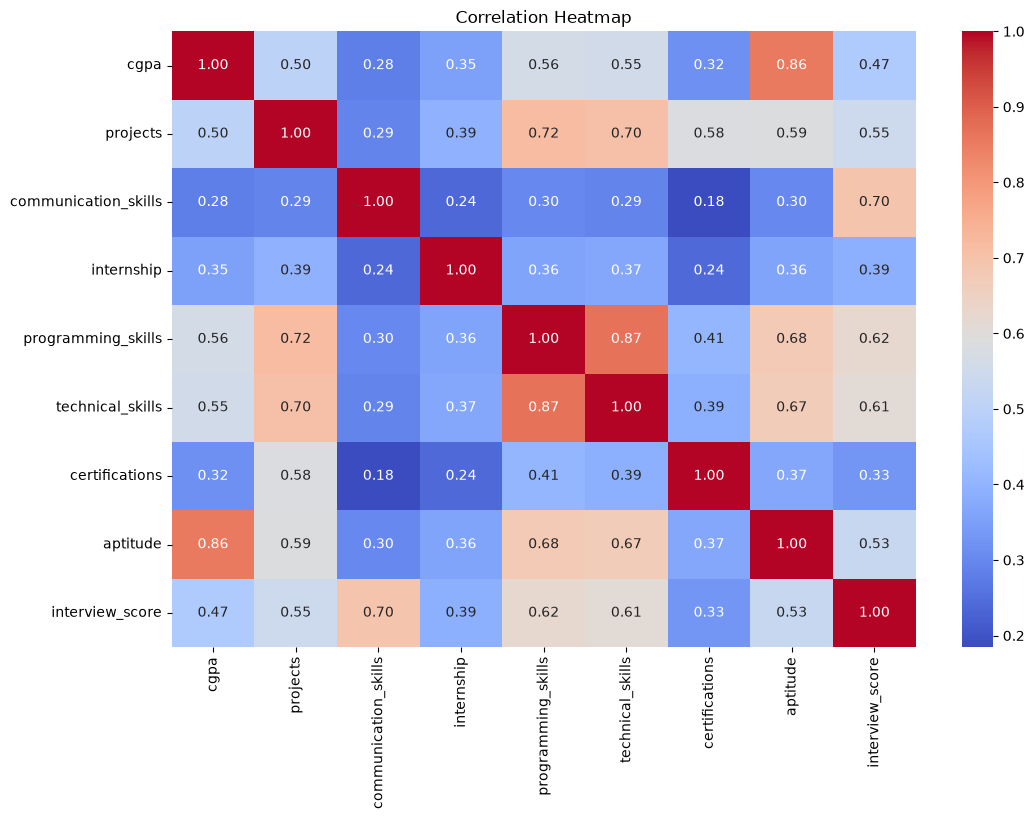

In [112]:
plt.figure(figsize=(12, 8))

sns.heatmap(df[numeric_cols].corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')

plt.title('Correlation Heatmap')
plt.show()

In [113]:
x = df.drop(columns = ['placement_status', 'package_range'])
y = df['placement_status']

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [116]:
x_train.shape, x_test.shape

((3010, 9), (1290, 9))

In [117]:
y_train.shape, y_test.shape

((3010,), (1290,))

In [118]:
from sklearn.preprocessing import StandardScaler

In [119]:
scaler = StandardScaler()

In [120]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [122]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, f1_score, confusion_matrix

In [132]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter = 2000, random_state = 42),
    'Decision Tree' : DecisionTreeClassifier(random_state = 42),
    'Random Forest' : RandomForestClassifier(n_estimators = 100, random_state = 42),
    'Extra Trees' : ExtraTreesClassifier(n_estimators = 100, random_state = 42),
    'AdaBoost' : AdaBoostClassifier(random_state = 42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state = 42),
    'KNN' : KNeighborsClassifier(n_neighbors = 10),
    'SVC' : SVC(),
    'XGBoost' : XGBClassifier()
}

In [133]:
def model_predict(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    result = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'recall' : recall_score(y_test, y_pred),
        'f1' : f1_score(y_test, y_pred)
    }

    return result, y_pred

In [134]:
results = {}

for name , model in models.items():
    results[name], y_pred = model_predict(model)

    print("=" * 60)
    print(f"Classification Report - {name}")
    print("=" * 60)
    print(classification_report(y_test, y_pred))

    print()
    print("=" * 60)
    print(f"Confusion Matrix - {name}")
    print("=" * 60)
    print(confusion_matrix(y_test, y_pred))

result_df = pd.DataFrame(results).T
print(result_df)

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       480
           1       0.92      0.94      0.93       810

    accuracy                           0.91      1290
   macro avg       0.91      0.90      0.90      1290
weighted avg       0.91      0.91      0.91      1290


Confusion Matrix - Logistic Regression
[[411  69]
 [ 45 765]]
Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       480
           1       0.86      0.85      0.85       810

    accuracy                           0.82      1290
   macro avg       0.81      0.81      0.81      1290
weighted avg       0.82      0.82      0.82      1290


Confusion Matrix - Decision Tree
[[369 111]
 [123 687]]
Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       4

In [135]:
import pickle

In [136]:
model = LogisticRegression(max_iter = 2000, random_state = 42)
model.fit(x_train, y_train)

with open('student_performance.pkl', 'wb') as file:
    pickle.dump(model, file)